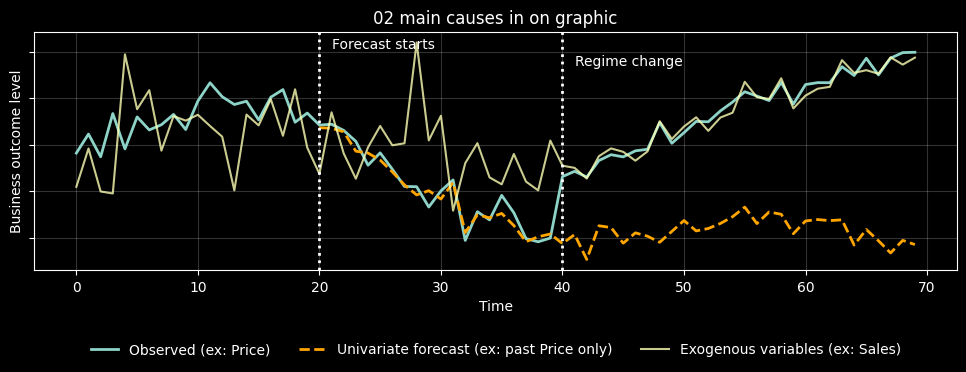

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Style fond noir
plt.style.use("dark_background")

np.random.seed(2)
T = 70
t = np.arange(T)

pred_start = 20      # début du forecasting
break_t = 40         # changement de régime

# =========================================================
# Latent signal used by the univariate forecast
# =========================================================
x = 0.9 * np.sin(t / 8) + 0.2 * np.random.randn(T)
x[pred_start:] = x[pred_start:] - 0.06 * (t[pred_start:] - pred_start)

# =========================================================
# Observed series (Price) with regime change
# =========================================================
y_obs = np.empty(T)
y_obs[:break_t] = 1.0 * x[:break_t] + 0.15 * np.random.randn(break_t)

up_trend = 0.09 * (t[break_t:] - break_t)
y_obs[break_t:] = (
    0.3 * x[break_t:]
    + up_trend
    + 0.15 * np.random.randn(T - break_t)
)

# =========================================================
# Univariate forecast (past Y only)
# =========================================================
y_pred = np.full(T, np.nan)
for i in range(pred_start, T):
    y_pred[i] = 1.0 * x[i]

# =========================================================
# Exogenous variable (Sales)
# =========================================================
X_exog = np.empty(T)
X_exog[:break_t] = 0.3 * y_obs[:break_t] + 0.6 * np.random.randn(break_t)
X_exog[break_t:] = 0.95 * y_obs[break_t:] + 0.15 * np.random.randn(T - break_t)

# =========================================================
# Plot (single panel)
# =========================================================
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, y_obs, label="Observed (ex: Price)", linewidth=2)

ax.plot(
    t,
    y_pred,
    label="Univariate forecast (ex: past Price only)",
    linestyle="--",
    linewidth=2,
    color="orange"
)

ax.plot(t, X_exog, label="Exogenous variables (ex: Sales)", alpha=0.8)

ax.axvline(pred_start, linestyle=":", linewidth=2)
ax.text(pred_start + 1, ax.get_ylim()[1]*0.85, "Forecast starts", fontsize=10)

ax.axvline(break_t, linestyle=":", linewidth=2)
ax.text(break_t + 1, ax.get_ylim()[1]*0.70, "Regime change", fontsize=10)

ax.set_title("02 main causes in on graphic")
ax.set_xlabel("Time")
ax.set_ylabel("Business outcome level")

# ✅ SEULE LIGNE AJOUTÉE : enlève les valeurs numériques de l’axe Y
ax.tick_params(axis='y', labelleft=False)

ax.grid(alpha=0.2)

# ---- Legend at the bottom (no visual interference) ----
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()